In [414]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler , PolynomialFeatures , OneHotEncoder
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from category_encoders import BinaryEncoder
from sklearn.impute import KNNImputer , SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate , GridSearchCV ,StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score , f1_score , recall_score , precision_score , confusion_matrix , ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
import seaborn as sns 
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline as skl_make_pipeline
from imblearn.pipeline import make_pipeline as imblearn_make_pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint

In [293]:
df = pd.read_csv(r"E:\datasites\used_cars_data.csv")

In [294]:
df

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,7248,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,NaN
7249,7249,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,First,17.21 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN
7250,7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,NaN
7251,7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,Third,17.2 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN


In [295]:
df.isna().sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
dtype: int64

In [296]:
def convert_mileage(value):
    if pd.isna(value):  
        return value
    if 'km/kg' in value:
        km_per_kg = float(value.split()[0])
        km_per_l = km_per_kg * 1.5  
        return f"{km_per_l:.2f} kmpl"
    elif 'kmpl' in value:
        return value
    return value

df['Mileage'] = df['Mileage'].apply(convert_mileage)


In [297]:
def remove_kmpl(value):
    if pd.isna(value):  
        return value
    if isinstance(value, str) and 'kmpl' in value:  
        return float(value.split()[0])
    return value  

df['Mileage'] = df['Mileage'].apply(remove_kmpl)

In [298]:
def remove_cc(value):
    if pd.isna(value):
        return value
    if isinstance(value, str) and 'CC' in value:
        return float(value.split()[0])
    return value

df['Engine'] = df['Engine'].apply(remove_cc)

In [299]:
def remove_bhp(value):
    if pd.isna(value):  
        return value
    try:
        if 'bhp' in value:
            return float(value.split()[0])  
    except (ValueError, AttributeError):
        pass  
    return np.nan  

df['Power'] = df['Power'].apply(remove_bhp)

In [300]:
df.columns = df.columns.str.replace('Mileage', 'Mileage_kmpl')
df.columns = df.columns.str.replace('Engine', 'Engine_CC')
df.columns = df.columns.str.replace('Power', 'Power_bhp')
df.drop(["New_Price","S.No."],axis=1,inplace=True)

In [301]:
def extract_type_and_model(car_name):
    parts = car_name.split(' ')  
    car_type = parts[0]  
    car_model = parts[1]
    return pd.Series([car_type, car_model])
df[['Type of Car', 'Car Model']] = df['Name'].apply(extract_type_and_model)

In [302]:
df['Seats'] = df.groupby(['Type of Car', 'Car Model'])['Seats'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 5))
df["Seats"]=df["Seats"].replace(0,4)#by search
df["Seats"]=df["Seats"].astype("int")
df.loc[[340, 358, 1860, 2328], "Kilometers_Driven"] = np.nan
df.loc[df[df["Mileage_kmpl"] == 0].index,"Mileage_kmpl"]=np.nan
def lakhs_to_inr(lakhs):
    return lakhs * 100000
df["Price"]=df["Price"].apply(lakhs_to_inr)     

In [303]:

df.columns=df.columns.str.replace("Price","Price_INR")
#df["Engine_CC"]=df["Engine_CC"].astype("int")
df["Year"]=df["Year"].astype("int")
df["Seats"]=df["Seats"].astype("int")
df.drop([4446, 4904], axis=0, inplace=True)     # it is 2 electric car not necessary
df.reset_index(drop=True, inplace=True)

In [304]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_CC,Power_bhp,Seats,Price_INR,Type of Car,Car Model
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000.0,CNG,Manual,First,39.90,998.0,58.16,5,175000.0,Maruti,Wagon
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5,1250000.0,Hyundai,Creta
2,Honda Jazz V,Chennai,2011,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5,450000.0,Honda,Jazz
3,Maruti Ertiga VDI,Chennai,2012,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7,600000.0,Maruti,Ertiga
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5,1774000.0,Audi,A4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7246,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411.0,Diesel,Manual,First,20.54,1598.0,103.60,5,NaN,Volkswagen,Vento
7247,Volkswagen Polo GT TSI,Mumbai,2015,59000.0,Petrol,Automatic,First,17.21,1197.0,103.60,5,NaN,Volkswagen,Polo
7248,Nissan Micra Diesel XV,Kolkata,2012,28000.0,Diesel,Manual,First,23.08,1461.0,63.10,5,NaN,Nissan,Micra
7249,Volkswagen Polo GT TSI,Pune,2013,52262.0,Petrol,Automatic,Third,17.20,1197.0,103.60,5,NaN,Volkswagen,Polo


In [305]:
df = df.drop(["Name"],axis=1)

In [306]:
df

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_CC,Power_bhp,Seats,Price_INR,Type of Car,Car Model
0,Mumbai,2010,72000.0,CNG,Manual,First,39.90,998.0,58.16,5,175000.0,Maruti,Wagon
1,Pune,2015,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5,1250000.0,Hyundai,Creta
2,Chennai,2011,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5,450000.0,Honda,Jazz
3,Chennai,2012,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7,600000.0,Maruti,Ertiga
4,Coimbatore,2013,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5,1774000.0,Audi,A4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7246,Hyderabad,2011,89411.0,Diesel,Manual,First,20.54,1598.0,103.60,5,NaN,Volkswagen,Vento
7247,Mumbai,2015,59000.0,Petrol,Automatic,First,17.21,1197.0,103.60,5,NaN,Volkswagen,Polo
7248,Kolkata,2012,28000.0,Diesel,Manual,First,23.08,1461.0,63.10,5,NaN,Nissan,Micra
7249,Pune,2013,52262.0,Petrol,Automatic,Third,17.20,1197.0,103.60,5,NaN,Volkswagen,Polo


In [307]:
for col in df.select_dtypes(include="O").columns:
    print(f"col: {col}, Unique values: {df[col].nunique()}")

col: Location, Unique values: 11
col: Fuel_Type, Unique values: 4
col: Transmission, Unique values: 2
col: Owner_Type, Unique values: 4
col: Type of Car, Unique values: 33
col: Car Model, Unique values: 217


In [308]:
print(df["Location"].unique())
print("*"*50)
print(df["Fuel_Type"].unique())
print("*"*50)
print(df["Transmission"].unique())
print("*"*50)
print(df["Owner_Type"].unique())
print("*"*50)
print(df["Type of Car"].unique())
print("*"*50)
print(df["Car Model"].unique())

['Mumbai' 'Pune' 'Chennai' 'Coimbatore' 'Hyderabad' 'Jaipur' 'Kochi'
 'Kolkata' 'Delhi' 'Bangalore' 'Ahmedabad']
**************************************************
['CNG' 'Diesel' 'Petrol' 'LPG']
**************************************************
['Manual' 'Automatic']
**************************************************
['First' 'Second' 'Fourth & Above' 'Third']
**************************************************
['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra' 'Ford'
 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda' 'Mini' 'Fiat'
 'Jeep' 'Smart' 'Ambassador' 'Isuzu' 'ISUZU' 'Force' 'Bentley'
 'Lamborghini' 'Hindustan' 'OpelCorsa']
**************************************************
['Wagon' 'Creta' 'Jazz' 'Ertiga' 'A4' 'EON' 'Micra' 'Innova' 'Vento'
 'Indica' 'Ciaz' 'City' 'Swift' 'Rover' 'Pajero' 'Amaze' 'Duster' 'New'
 '3' 'S' 'A6' 'i20' 'Alto' 'WRV' 'Corolla' 'Ssangyong' 'Vitara' 'KUV'
 'M-

In [309]:
df.drop(df[df["Price_INR"].isna()].index ,axis=0 , inplace=True)

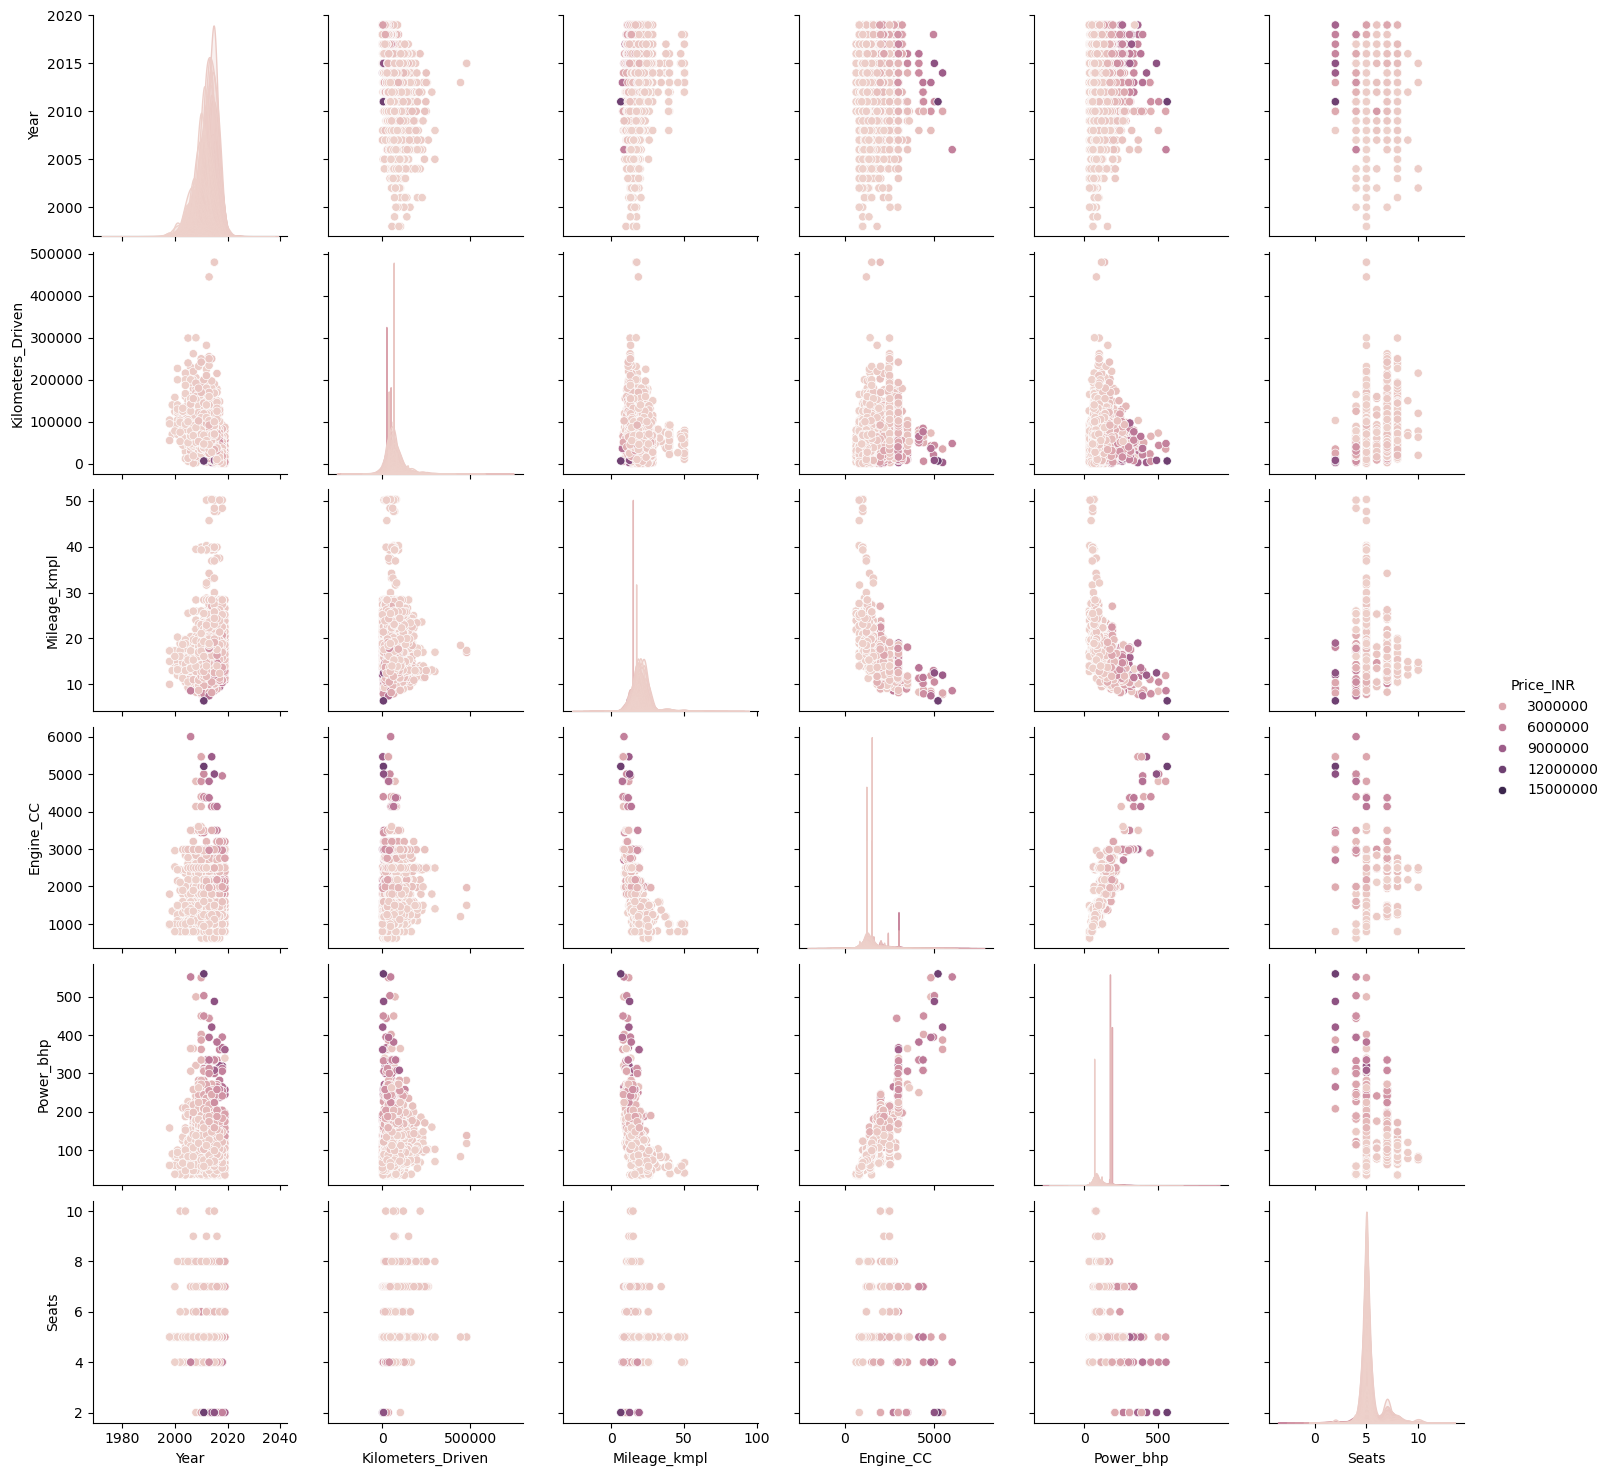

In [310]:
sns.pairplot(data=df,hue="Price_INR")

In [311]:
st=StandardScaler()


In [312]:
from category_encoders import BinaryEncoder

In [313]:
df["Location"].unique()

array(['Mumbai', 'Pune', 'Chennai', 'Coimbatore', 'Hyderabad', 'Jaipur',
       'Kochi', 'Kolkata', 'Delhi', 'Bangalore', 'Ahmedabad'],
      dtype=object)

In [314]:
df

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_CC,Power_bhp,Seats,Price_INR,Type of Car,Car Model
0,Mumbai,2010,72000.0,CNG,Manual,First,39.90,998.0,58.16,5,175000.0,Maruti,Wagon
1,Pune,2015,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5,1250000.0,Hyundai,Creta
2,Chennai,2011,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5,450000.0,Honda,Jazz
3,Chennai,2012,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7,600000.0,Maruti,Ertiga
4,Coimbatore,2013,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5,1774000.0,Audi,A4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6012,Delhi,2014,27365.0,Diesel,Manual,First,28.40,1248.0,74.00,5,475000.0,Maruti,Swift
6013,Jaipur,2015,100000.0,Diesel,Manual,First,24.40,1120.0,71.00,5,400000.0,Hyundai,Xcent
6014,Jaipur,2012,55000.0,Diesel,Manual,Second,14.00,2498.0,112.00,8,290000.0,Mahindra,Xylo
6015,Kolkata,2013,46000.0,Petrol,Manual,First,18.90,998.0,67.10,5,265000.0,Maruti,Wagon


In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6017 entries, 0 to 6016
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           6017 non-null   object 
 1   Year               6017 non-null   int32  
 2   Kilometers_Driven  6013 non-null   float64
 3   Fuel_Type          6017 non-null   object 
 4   Transmission       6017 non-null   object 
 5   Owner_Type         6017 non-null   object 
 6   Mileage_kmpl       5949 non-null   float64
 7   Engine_CC          5981 non-null   float64
 8   Power_bhp          5874 non-null   float64
 9   Seats              6017 non-null   int32  
 10  Price_INR          6017 non-null   float64
 11  Type of Car        6017 non-null   object 
 12  Car Model          6017 non-null   object 
dtypes: float64(5), int32(2), object(6)
memory usage: 564.2+ KB


In [316]:
df.isna().sum()

Location               0
Year                   0
Kilometers_Driven      4
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage_kmpl          68
Engine_CC             36
Power_bhp            143
Seats                  0
Price_INR              0
Type of Car            0
Car Model              0
dtype: int64

In [317]:
df.select_dtypes("number").corr()

,Year,Kilometers_Driven,Mileage_kmpl,Engine_CC,Power_bhp,Seats,Price_INR
Year,1.000000,-0.481528,0.270564,-0.051848,0.014612,0.014741,0.305355
Kilometers_Driven,-0.481528,1.000000,-0.141311,0.168155,0.004480,0.232791,-0.178992
Mileage_kmpl,0.270564,-0.141311,1.000000,-0.613159,-0.528890,-0.325101,-0.317889
Engine_CC,-0.051848,0.168155,-0.613159,1.000000,0.866303,0.397492,0.658855
Power_bhp,0.014612,0.004480,-0.528890,0.866303,1.000000,0.101487,0.772837
Seats,0.014741,0.232791,-0.325101,0.397492,0.101487,1.000000,0.053544
Price_INR,0.305355,-0.178992,-0.317889,0.658855,0.772837,0.053544,1.000000


In [318]:
df.isna().sum()

Location               0
Year                   0
Kilometers_Driven      4
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage_kmpl          68
Engine_CC             36
Power_bhp            143
Seats                  0
Price_INR              0
Type of Car            0
Car Model              0
dtype: int64

In [320]:
df.columns

Index(['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
       'Owner_Type', 'Mileage_kmpl', 'Engine_CC', 'Power_bhp', 'Seats',
       'Price_INR', 'Type of Car', 'Car Model'],
      dtype='object')

In [390]:
x=df.drop(['Price_INR','Type of Car','Car Model'],axis=1)
y_log = np.log1p(df["Price_INR"].values.reshape(-1,1))
y_scaled = st.fit_transform(y_log)

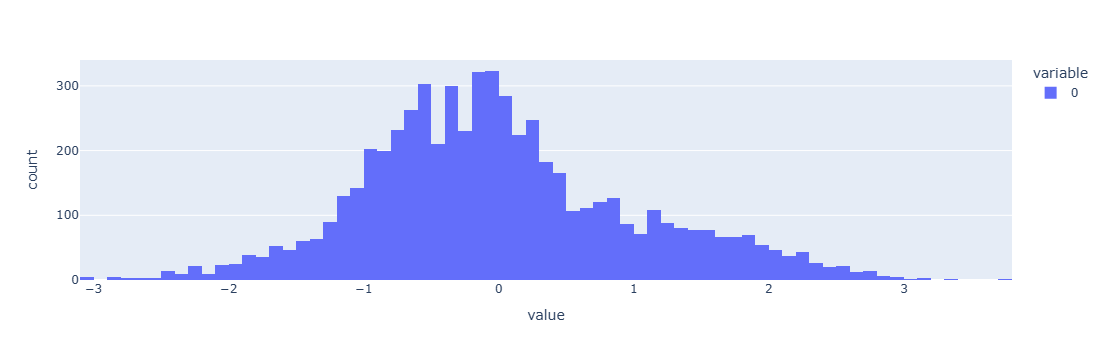

In [322]:
px.histogram(data_frame=y_scaled)

In [323]:
df.columns

Index(['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
       'Owner_Type', 'Mileage_kmpl', 'Engine_CC', 'Power_bhp', 'Seats',
       'Price_INR', 'Type of Car', 'Car Model'],
      dtype='object')

# prepossing

In [319]:
transmission_order = [['Manual', 'Automatic']]
trans_pipe = Pipeline([
    ('ordinal', OrdinalEncoder(categories=transmission_order))
])
owner_order = [['Fourth & Above', 'Third', 'Second', 'First']]
owner_pipe = Pipeline([
    ('ordinal', OrdinalEncoder(categories=owner_order))
])
binary_features=["Location"]
location_pipe= Pipeline([("location_binary", BinaryEncoder())])


In [324]:

prepossing = ColumnTransformer(transformers=[
    ("knn_pipe",KNNImputer(n_neighbors=3) ,['Mileage_kmpl', 'Engine_CC', 'Power_bhp']),
    ("simple_pipe",SimpleImputer(strategy="mean"),["Kilometers_Driven"] ),
    ("trans_pipe", trans_pipe, ["Transmission"]),
    ("owner_pipe", owner_pipe, ["Owner_Type"]),
    ("fuel_pipe", OneHotEncoder(drop='first',sparse_output=False), ["Fuel_Type"]),
    ("binary_pipe", location_pipe, binary_features)
])


# LinearRegression

In [326]:
model= make_pipeline(prepossing , PolynomialFeatures(degree=3) ,StandardScaler() , LinearRegression())
sc = cross_validate(
    estimator=model,
    X=x,
    y=y_scaled,
    scoring=["neg_mean_squared_error", "r2"], 
    return_train_score=True,
    cv=KFold(n_splits=5, shuffle=True, random_state=42)
)
print(f"Train_MSE:{sc['train_neg_mean_squared_error'].mean()}")
print(f"Test_MSE:{sc['test_neg_mean_squared_error'].mean()}")
print(f"Train_r2:{sc['train_r2'].mean()}")
print(f"Test_r2:{sc['test_r2'].mean()}")


Train_MSE:-0.05954958799415133
Test_MSE:-4071.505562139827
Train_r2:0.9404463796786589
Test_r2:-4122.472280785014


# DecisionTreeRegressor

In [394]:
model= make_pipeline(prepossing ,StandardScaler() , DecisionTreeRegressor())
sc = cross_validate(
    estimator=model,
    X=x,
    y=y_scaled,
    scoring=["neg_mean_squared_error", "r2"], 
    return_train_score=True,
    cv=KFold(n_splits=5, shuffle=True, random_state=42)
)
print(f"Train_MSE:{sc['train_neg_mean_squared_error'].mean()}")
print(f"Test_MSE:{sc['test_neg_mean_squared_error'].mean()}")
print(f"Train_r2:{sc['train_r2'].mean()}")
print(f"Test_r2:{sc['test_r2'].mean()}")


Train_MSE:-0.00010306039480448815
Test_MSE:-0.2293371401356649
Train_r2:0.9998969380921302
Test_r2:0.7699576307842565


In [398]:
model= make_pipeline(prepossing ,StandardScaler() ,DecisionTreeRegressor())
param_grid = {
    "decisiontreeregressor__max_depth": [None, 5, 10, 20, 30],
    "decisiontreeregressor__min_samples_split": [2, 5, 10],
    "decisiontreeregressor__min_samples_leaf": [1, 2, 4],
    "decisiontreeregressor__max_features": [None, "sqrt", "log2"],
    "decisiontreeregressor__criterion": ["squared_error", "friedman_mse"]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(x,y_scaled)

print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", grid_search.best_score_)

Best Parameters: {'decisiontreeregressor__criterion': 'squared_error', 'decisiontreeregressor__max_depth': 10, 'decisiontreeregressor__max_features': None, 'decisiontreeregressor__min_samples_leaf': 4, 'decisiontreeregressor__min_samples_split': 10}
Best Score (MSE): -0.1916856188032793


In [406]:
best_decision_model = grid_search.best_estimator_
r2_cv = cross_validate(best_decision_model, x, y_scaled,cv=KFold(n_splits=5, shuffle=True, random_state=42) , scoring='r2')
print("R² per fold:", r2_cv['test_score'])
print("Mean R² (CV):", np.mean(r2_cv['test_score']))

R² per fold: [0.80181911 0.82346295 0.81385786 0.7915084  0.80873089]
Mean R² (CV): 0.8078758411288532


# RandomForestRegressor

In [409]:
model= make_pipeline(prepossing ,StandardScaler() ,RandomForestRegressor())
sc = cross_validate(
    estimator=model,
    X=x,
    y=y_scaled,
    scoring=["neg_mean_squared_error", "r2"], 
    return_train_score=True,
    cv=KFold(n_splits=5, shuffle=True, random_state=42)
)
print(f"Train_MSE:{sc['train_neg_mean_squared_error'].mean()}")
print(f"Test_MSE:{sc['test_neg_mean_squared_error'].mean()}")
print(f"Train_r2:{sc['train_r2'].mean()}")
print(f"Test_r2:{sc['test_r2'].mean()}")


C:\Users\NOUR SOFT\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

C:\Users\NOUR SOFT\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

C:\Users\NOUR SOFT\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

C:\Users\NOUR SOFT\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

C:\Users\NOUR SOFT\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning:

A c

Train_MSE:-0.01789740945427795
Test_MSE:-0.12484904979914335
Train_r2:0.9821014535850668
Test_r2:0.8747278417667086


In [ ]:
param_dist = {
    'randomforestregressor__n_estimators': [100, 200, 300, 400, 500],
    'randomforestregressor__max_depth': [None] + list(range(5, 30)),
    'randomforestregressor__min_samples_split': list(range(2, 21)),  
    'randomforestregressor__min_samples_leaf': list(range(1, 11)),   
    'randomforestregressor__max_features': ['auto', 'sqrt', 'log2']
}
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_dist,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(x,y_scaled)

print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", grid_search.best_score_)
best_Random_model = grid_search.best_estimator_
r2_cv = cross_validate(best_Random_model, x, y_scaled,cv=KFold(n_splits=5, shuffle=True, random_state=42) , scoring='r2')
print("R² per fold:", r2_cv['test_score'])
print("Mean R² (CV):", np.mean(r2_cv['test_score']))